# Scaling experiment

Measure how the Stegosaurus worker pool behaves under load.

Three experiments:
1. **Baseline** - single worker; latency vs concurrency level
2. **Worker sweep** - fixed concurrency; vary `MAX_WORKERS`; observe latency + throughput
3. **Dynamic scaling trace** - send a traffic burst and watch the pool auto-scale in real time

## 1. Set-up

In [ ]:
import threading
import time

import matplotlib.pyplot as plt
import pandas as pd

from helpers import burst, count_workers, decode_one, encode_one, sample_workers, summarize


### 1.1. Configuration

Edit `APP_URL` to point at a running Stegosaurus instance.

In [11]:
APP_URL = 'http://localhost:8080'

# Payload used for every encode request
PROMPT = 'Write a short story about a lighthouse keeper.'
MESSAGE = 'hello'

# Section 2 - baseline
BASELINE_CONCURRENCY_LEVELS = [1, 2, 4, 8]
BASELINE_REQUESTS_PER_LEVEL = 10

# Section 3 - worker sweep
SWEEP_CONCURRENCY = 8             # fixed concurrent callers
SWEEP_REQUESTS = 20               # requests per max_workers setting
SWEEP_MAX_WORKERS = [1, 2, 4, 8]  # restart app between each

# Section 4 - dynamic scaling
BURST_CONCURRENCY = 8
BURST_REQUESTS = 30
SAMPLE_INTERVAL_S = 1.0           # how often to count worker processes

### 1.2. Client helpers

In [ ]:
# encode_one(app_url, prompt, message)  -> elapsed seconds
# decode_one(app_url, prompt, cover_text) -> elapsed seconds
# burst(app_url, prompt, message, n_requests, n_workers) -> (times, wall)
# summarize(times, wall) -> stats dict
# All defined in helpers.py.


## 2. Baseline single worker

Start the app with `MAX_WORKERS=1 MIN_WORKERS=1`, then run the cell below.
Each concurrency level fires `BASELINE_REQUESTS_PER_LEVEL` requests with that many parallel threads.

In [ ]:
baseline_rows = []

for concurrency in BASELINE_CONCURRENCY_LEVELS:
    times, wall = burst(APP_URL, PROMPT, MESSAGE, BASELINE_REQUESTS_PER_LEVEL, concurrency)
    stats = summarize(times, wall)
    baseline_rows.append({'concurrency': concurrency, **stats})

df_baseline = pd.DataFrame(baseline_rows)
df_baseline


,concurrency,n,min_s,median_s,p95_s,max_s,throughput_rps
0,1,10,6.98,7.04,7.14,7.14,0.14
1,2,10,6.78,7.11,14.00,14.00,0.23
2,4,10,7.19,7.36,14.44,14.44,0.44
3,8,10,7.56,14.42,15.05,15.05,0.45


### 2.1. Latency vs concurrency

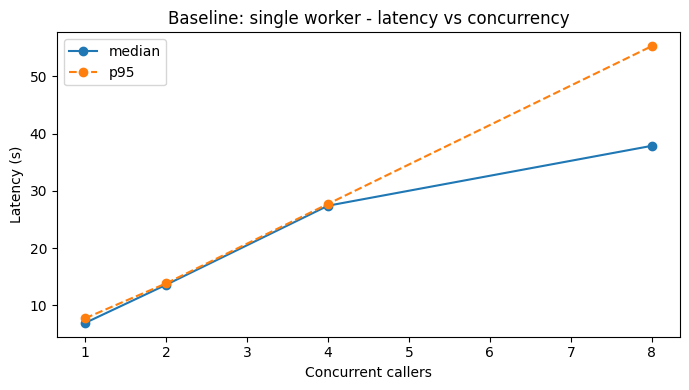

In [6]:
x = df_baseline['concurrency']
fig, ax = plt.subplots(figsize=(7, 4))
ax.set_title('Baseline: single worker - latency vs concurrency')
ax.plot(x, df_baseline['median_s'], marker='o', label='median')
ax.plot(x, df_baseline['p95_s'], marker='o', linestyle='--', label='p95')
ax.set_xlabel('Concurrent callers')
ax.set_ylabel('Latency (s)')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Worker sweep

For each value in `SWEEP_MAX_WORKERS`:
1. Restart the app with `MAX_WORKERS=<n> MIN_WORKERS=<n>` (so the pool is pre-warmed).
2. Set `N_WORKERS_THIS_RUN = <n>` in the cell below.
3. Run the measurement cell.
4. Repeat for the next value.

The cell accumulates results into `df_sweep` across re-runs.

In [ ]:
# Set this to match the MAX_WORKERS value the app was started with, then run the cell.
# Re-run with a different value after restarting the app with a new MAX_WORKERS setting.
N_WORKERS_THIS_RUN = 8

# Accumulates into sweep_rows across multiple cell executions.
try:
    sweep_rows

except NameError:
    sweep_rows = []

times, wall = burst(APP_URL, PROMPT, MESSAGE, SWEEP_REQUESTS, SWEEP_CONCURRENCY)
stats = summarize(times, wall)
sweep_rows.append({'max_workers': N_WORKERS_THIS_RUN, **stats})

df_sweep = pd.DataFrame(sweep_rows).sort_values('max_workers')
df_sweep


,max_workers,n,min_s,median_s,p95_s,max_s,throughput_rps
0,1,20,6.90,53.00,54.28,54.28,0.15
1,2,20,8.07,28.11,29.30,29.30,0.28
2,4,20,8.45,14.84,16.33,16.33,0.51
3,8,20,7.33,8.65,9.84,9.84,0.76


### 3.1. Latency and throughput vs worker count

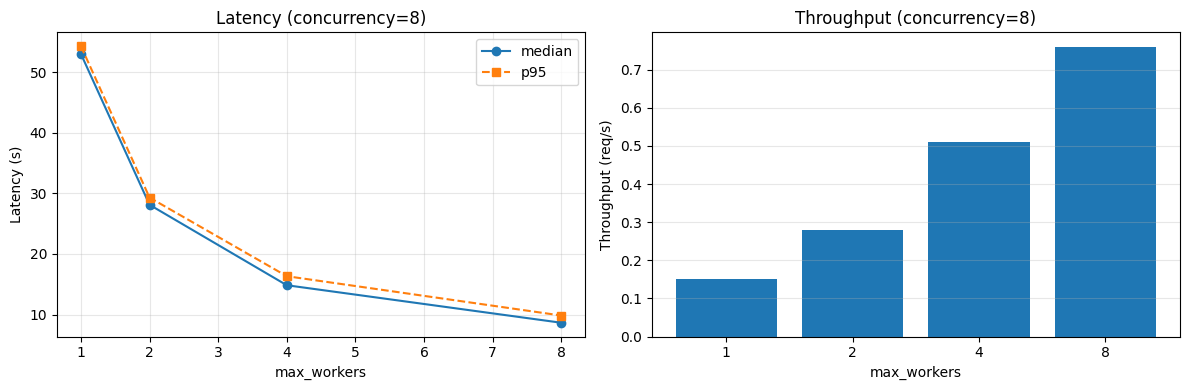

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

x = df_sweep['max_workers']

ax1.set_title(f'Latency (concurrency={SWEEP_CONCURRENCY})')
ax1.plot(x, df_sweep['median_s'], marker='o', label='median')
ax1.plot(x, df_sweep['p95_s'], marker='s', linestyle='--', label='p95')
ax1.set_xlabel('max_workers')
ax1.set_ylabel('Latency (s)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_title(f'Throughput (concurrency={SWEEP_CONCURRENCY})')
ax2.bar(x.astype(str), df_sweep['throughput_rps'])
ax2.set_xlabel('max_workers')
ax2.set_ylabel('Throughput (req/s)')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 4. Dynamic scaling trace

Start the app with `MIN_WORKERS=1 MAX_WORKERS=4`.
The cell below:
1. Polls `pgrep` in a background thread to count live worker processes.
2. Fires a burst of requests.
3. Keeps sampling until the pool quiesces back to `MIN_WORKERS`.

The result is a step-plot of worker count over time.

In [ ]:
QUIESCE_STABLE_S = 10    # stop sampling once count is stable for this long
QUIESCE_TIMEOUT_S = 180  # give up waiting after this many seconds

# Allow a warm-up sample before the burst
samples = []
stop_event = threading.Event()
sampler = threading.Thread(
    target=sample_workers,
    args=(stop_event, samples, SAMPLE_INTERVAL_S),
    daemon=True,
)

print('Sampling worker count before burst…')
sampler.start()
time.sleep(3)

# Record the baseline pool size before the burst so the quiesce target
# reflects whatever MIN_WORKERS the app was actually started with.
baseline_count = samples[-1][1] if samples else 1
print(f'Baseline worker count: {baseline_count}')

print(f'Firing burst: {BURST_REQUESTS} requests at concurrency {BURST_CONCURRENCY}')
burst_times, burst_wall = burst(APP_URL, PROMPT, MESSAGE, BURST_REQUESTS, BURST_CONCURRENCY)
print(f'Burst complete in {burst_wall:.1f}s. Waiting for pool to quiesce…')

# Keep sampling until the count has returned to baseline and been stable
# for QUIESCE_STABLE_S, or until QUIESCE_TIMEOUT_S elapses.
prev_count = None
stable_since = time.perf_counter()
quiesce_deadline = time.perf_counter() + QUIESCE_TIMEOUT_S

while True:
    time.sleep(SAMPLE_INTERVAL_S)
    current = count_workers()

    if current != prev_count:
        stable_since = time.perf_counter()
        prev_count = current

    if current <= baseline_count and (time.perf_counter() - stable_since) >= QUIESCE_STABLE_S:
        break

    if time.perf_counter() >= quiesce_deadline:
        print(f'Warning: quiesce timeout reached; last worker count was {current} (baseline {baseline_count})')
        break

stop_event.set()
sampler.join()
print(f'Done. Collected {len(samples)} samples.')


Sampling worker count before burst…
Baseline worker count: 1
Firing burst: 30 requests at concurrency 8
Burst complete in 68.9s. Waiting for pool to quiesce…
Done. Collected 112 samples.


### 4.1. Worker count over time

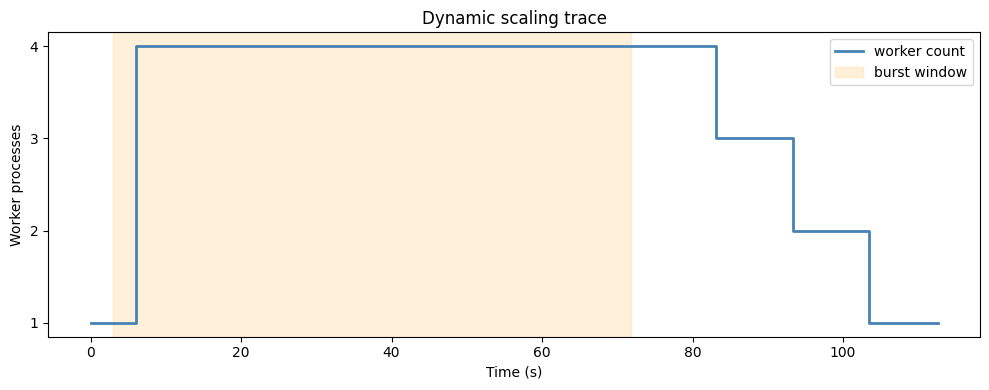

Burst summary: {'n': 30, 'min_s': 7.96, 'median_s': 14.76, 'p95_s': 28.99, 'max_s': 29.9, 'throughput_rps': 0.44}


In [ ]:
ts, counts = zip(*samples)

# Approximate burst window: t=3s to t=3+burst_wall
burst_start_t = 3.0
burst_end_t = burst_start_t + burst_wall

fig, ax = plt.subplots(figsize=(10, 4))
ax.set_title('Dynamic scaling trace')
ax.step(ts, counts, where='post', color='steelblue', linewidth=2, label='worker count')
ax.axvspan(burst_start_t, burst_end_t, alpha=0.15, color='orange', label='burst window')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Worker processes')
ax.yaxis.get_major_locator().set_params(integer=True)
ax.legend()
plt.tight_layout()
plt.show()